In [1]:
import tensorflow as tf
import pandas as pd

from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
images = []
labels = []

In [3]:
import cv2
import os

images = []
labels = []

def load_data(category, label):
    folder_path = f"train/{category}"

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (48, 48))

            images.append(img)
            labels.append(label)

        except:
            pass

In [4]:
category = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "neutral": 4,
    "sad": 5,
    "surprise": 6
}

In [5]:
for e in category.items():
    load_data(e[0], e[1])


In [6]:
df = pd.DataFrame({
    "image": images,
    "label": labels
})

In [7]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [18]:
import numpy as np
X = np.array(df["image"].tolist(), dtype= np.float32)
y = np.array(df["label"].tolist())

X = X.reshape(-1, 48, 48, 1)
X = X / 255.0

## Test Data

In [25]:
X_test = []
y_test = []

In [26]:
def load_test_data(category, label):
    folder_path = f"test/{category}"

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (48, 48))

            X_test.append(img)
            y_test.append(label)

        except:
            pass

In [27]:
for e in category.items():
    load_test_data(e[0], e[1])


In [28]:
import numpy as np

X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test)

X_test = X_test.reshape(-1, 48, 48, 1)
X_test = X_test / 255.0

In [14]:
print(X.shape)
print(X.dtype)
print(type(X[0]))

(28709, 48, 48, 1)
float32
<class 'numpy.ndarray'>


In [63]:
from tensorflow.keras import models, layers, regularizers

model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        kernel_regularizer=regularizers.l2(0.0001),
                        input_shape=(48,48,1)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.2))

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu',
                        kernel_regularizer=regularizers.l2(0.0001)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.2))

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.2))

# GAP instead of Flatten
model.add(layers.GlobalAveragePooling2D())

# Dense
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.3))

# Output
model.add(layers.Dense(len(set(y)), activation='softmax'))

In [64]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,391 (501.53 KB)

 Trainable params: 127,943 (499.78 KB)

 Non-trainable params: 448 (1.75 KB)

## Add Dense Layer

In [ ]:
# model.add(layers.Flatten())
# model.add(layers.Dense(64, activation='relu'))
# model.add(layers.Dense(10))

In [65]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

In [66]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X, y,
    epochs=70,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    batch_size=32
)

Epoch 1/70
898/898 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.2863 - loss: 1.7695 - val_accuracy: 0.2640 - val_loss: 2.0887
Epoch 2/70
898/898 ━━━━━━━━━━━━━━━━━━━━ 74s 83ms/step - accuracy: 0.3833 - loss: 1.5816 - val_accuracy: 0.3522 - val_loss: 1.8491
Epoch 3/70
898/898 ━━━━━━━━━━━━━━━━━━━━ 73s 82ms/step - accuracy: 0.4358 - loss: 1.4696 - val_accuracy: 0.4195 - val_loss: 1.5337
Epoch 4/70
898/898 ━━━━━━━━━━━━━━━━━━━━ 77s 85ms/step - accuracy: 0.4660 - loss: 1.3979 - val_accuracy: 0.4915 - val_loss: 1.3214
Epoch 5/70
898/898 ━━━━━━━━━━━━━━━━━━━━ 75s 84ms/step - accuracy: 0.4897 - loss: 1.3420 - val_accuracy: 0.5091 - val_loss: 1.2857
Epoch 6/70
898/898 ━━━━━━━━━━━━━━━━━━━━ 75s 83ms/step - accuracy: 0.5074 - loss: 1.3042 - val_accuracy: 0.5004 - val_loss: 1.3001
Epoch 7/70
898/898 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - accuracy: 0.5202 - loss: 1.2706 - val_accuracy: 0.5393 - val_loss: 1.2084
Epoch 8/70
898/898 ━━━━━━━━━━━━━━━━━━━━ 76s 85ms/step - accuracy: 0.5291 - loss: 1.2399 - 

225/225 - 2s - 11ms/step - accuracy: 0.5952 - loss: 1.0805


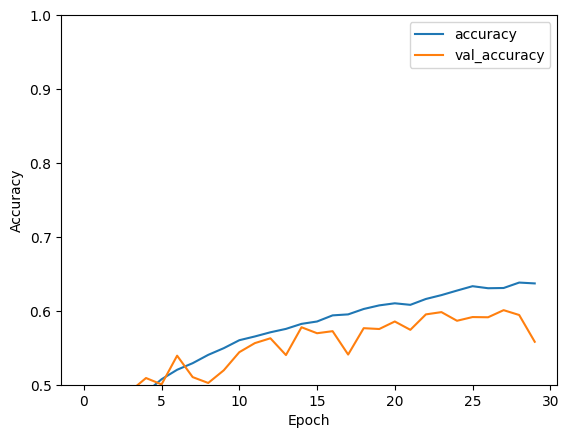

In [67]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend()

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

In [68]:
model.save("emotion_model.h5")

## Test for sample data

In [74]:
emotion = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

In [79]:
img_path = "test/sad/PublicTest_99393604.jpg"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (48, 48))

img = img.reshape(1, 48, 48, 1)
img = img.astype("float32") / 255.0

ans = model.predict(img)

predicted_class = np.argmax(ans)
print(emotion[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
sad
